In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
print('导入完成')

导入完成


In [2]:
file_path = 'Final_Features_3.8.csv'
df = pd.read_csv(file_path)

excluded_cols = ['sample_id', 'tensile_strength', 'elongation', 'healing_eff']
feature_cols = [col for col in df.columns if col not in excluded_cols]

print(f'总样本数: {len(df)}')
print(f'Pearson 分析特征数: {len(feature_cols)}')
print('特征列表:')
for col in feature_cols:
    print(f'  - {col}')

pearson_data = df[feature_cols].copy()
constant_features = pearson_data.columns[pearson_data.nunique(dropna=True) <= 1].tolist()

if constant_features:
    print('\n⚠️ 存在常数特征，这些列在 Pearson 中可能为 NaN:')
    for col in constant_features:
        print(f'  - {col}')
else:
    print('\n✅ 未检测到常数特征')

总样本数: 85
Pearson 分析特征数: 21
特征列表:
  - Soft_Segment_Content
  - Furan_Content
  - Maleimide_Content
  - Hard_Segment_Content
  - NCO_OH_Ratio
  - Extra_Crosslinker_Content
  - Furan_Type
  - Network_Topology
  - Add_Crosslinker_Flag
  - Polyol_Class
  - Iso_Class
  - Extender_Class
  - Soft_Mw
  - Constraint_Factor
  - Hard_Symmetry
  - Soft_Cryst
  - Synergy_Feature
  - poly_tem
  - strain_rate
  - healing_temperature
  - healing_time

✅ 未检测到常数特征


In [3]:
# 覆盖更新：删除 Extender_Class 和 Add_Crosslinker_Flag
# 理由：
# 1. Extender_Class 与交联信息完全重合，已确认冗余
# 2. Add_Crosslinker_Flag 与 Extra_Crosslinker_Content Pearson=1.000
# 3. 保留连续特征 Extra_Crosslinker_Content 更有信息量，既能表达“有没有”，也能表达“加了多少”
excluded_cols = [
    'sample_id', 'tensile_strength', 'elongation', 'healing_eff',
    'Extender_Class', 'Add_Crosslinker_Flag'
 ]
feature_cols = [col for col in df.columns if col not in excluded_cols]
pearson_data = df[feature_cols].copy()
constant_features = pearson_data.columns[pearson_data.nunique(dropna=True) <= 1].tolist()

print('已移除 Extender_Class 和 Add_Crosslinker_Flag')
print(f'更新后 Pearson 分析特征数: {len(feature_cols)}')
print('更新后的特征列表:')
for col in feature_cols:
    print(f'  - {col}')

if constant_features:
    print('\n⚠️ 存在常数特征，这些列在 Pearson 中可能为 NaN:')
    for col in constant_features:
        print(f'  - {col}')
else:
    print('\n✅ 未检测到常数特征')

已移除 Extender_Class 和 Add_Crosslinker_Flag
更新后 Pearson 分析特征数: 19
更新后的特征列表:
  - Soft_Segment_Content
  - Furan_Content
  - Maleimide_Content
  - Hard_Segment_Content
  - NCO_OH_Ratio
  - Extra_Crosslinker_Content
  - Furan_Type
  - Network_Topology
  - Polyol_Class
  - Iso_Class
  - Soft_Mw
  - Constraint_Factor
  - Hard_Symmetry
  - Soft_Cryst
  - Synergy_Feature
  - poly_tem
  - strain_rate
  - healing_temperature
  - healing_time

✅ 未检测到常数特征


In [18]:
corr_matrix = pearson_data.corr(method='pearson', numeric_only=True)

print('=' * 100)
print('全部候选特征 Pearson 相关性矩阵')
print('=' * 100)
display(corr_matrix.round(3))

print('\n✅ 高相关特征对检查（|r| > 0.85）')
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        f1 = corr_matrix.columns[i]
        f2 = corr_matrix.columns[j]
        r_val = corr_matrix.iloc[i, j]
        if pd.notna(r_val) and abs(r_val) > 0.85:
            high_corr_pairs.append((f1, f2, r_val))
            print(f'  {f1} ↔ {f2}: {r_val:.3f}')

if not high_corr_pairs:
    print('  未发现 |r| > 0.85 的特征对')

全部候选特征 Pearson 相关性矩阵


,Soft_Segment_Content,Furan_Content,Maleimide_Content,Hard_Segment_Content,NCO_OH_Ratio,Extra_Crosslinker_Content,DA_Linker_Type,Furan_Type,Network_Topology,Polyol_Class,Iso_Class,Soft_Mw,Constraint_Factor,Hard_Symmetry,Soft_Cryst,Synergy_Feature,poly_tem,strain_rate,healing_temperature,healing_time
Soft_Segment_Content,1.000,-0.441,-0.681,-0.351,0.352,-0.006,-0.432,0.030,-0.047,-0.318,-0.060,0.431,-0.396,-0.380,-0.323,-0.376,-0.088,0.135,0.339,0.306
Furan_Content,-0.441,1.000,0.664,-0.572,-0.688,-0.185,0.246,0.540,-0.117,0.470,-0.214,0.214,-0.393,-0.092,-0.300,-0.047,-0.073,-0.043,-0.392,-0.284
Maleimide_Content,-0.681,0.664,1.000,-0.376,-0.689,-0.181,0.372,0.377,-0.169,0.416,0.003,-0.003,-0.254,0.360,-0.055,0.312,0.144,0.032,-0.375,-0.308
Hard_Segment_Content,-0.351,-0.572,-0.376,1.000,0.518,0.214,0.068,-0.622,0.251,-0.225,0.188,-0.599,0.856,0.203,0.572,0.210,0.025,-0.151,0.124,0.042
NCO_OH_Ratio,0.352,-0.688,-0.689,0.518,1.000,0.172,-0.335,-0.674,0.328,-0.464,-0.080,-0.375,0.474,-0.242,0.435,-0.096,0.015,-0.024,0.237,0.348
Extra_Crosslinker_Content,-0.006,-0.185,-0.181,0.214,0.172,1.000,-0.208,-0.176,-0.040,-0.094,-0.103,-0.112,0.211,-0.100,0.085,-0.081,0.072,-0.066,0.128,0.289
DA_Linker_Type,-0.432,0.246,0.372,0.068,-0.335,-0.208,1.000,0.077,0.191,0.295,0.227,0.023,-0.031,0.196,0.222,0.224,0.190,-0.052,-0.067,-0.361
Furan_Type,0.030,0.540,0.377,-0.622,-0.674,-0.176,0.077,1.000,-0.354,0.270,-0.191,0.297,-0.460,0.038,-0.550,-0.046,0.031,0.161,-0.385,-0.495
Network_Topology,-0.047,-0.117,-0.169,0.251,0.328,-0.040,0.191,-0.354,1.000,-0.239,0.022,-0.223,0.232,-0.263,0.284,-0.162,0.027,-0.155,-0.101,0.285
Polyol_Class,-0.318,0.470,0.416,-0.225,-0.464,-0.094,0.295,0.270,-0.239,1.000,-0.236,0.058,-0.067,0.023,-0.022,0.136,0.126,-0.129,-0.560,-0.485



✅ 高相关特征对检查（|r| > 0.85）
  Hard_Segment_Content ↔ Constraint_Factor: 0.856


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

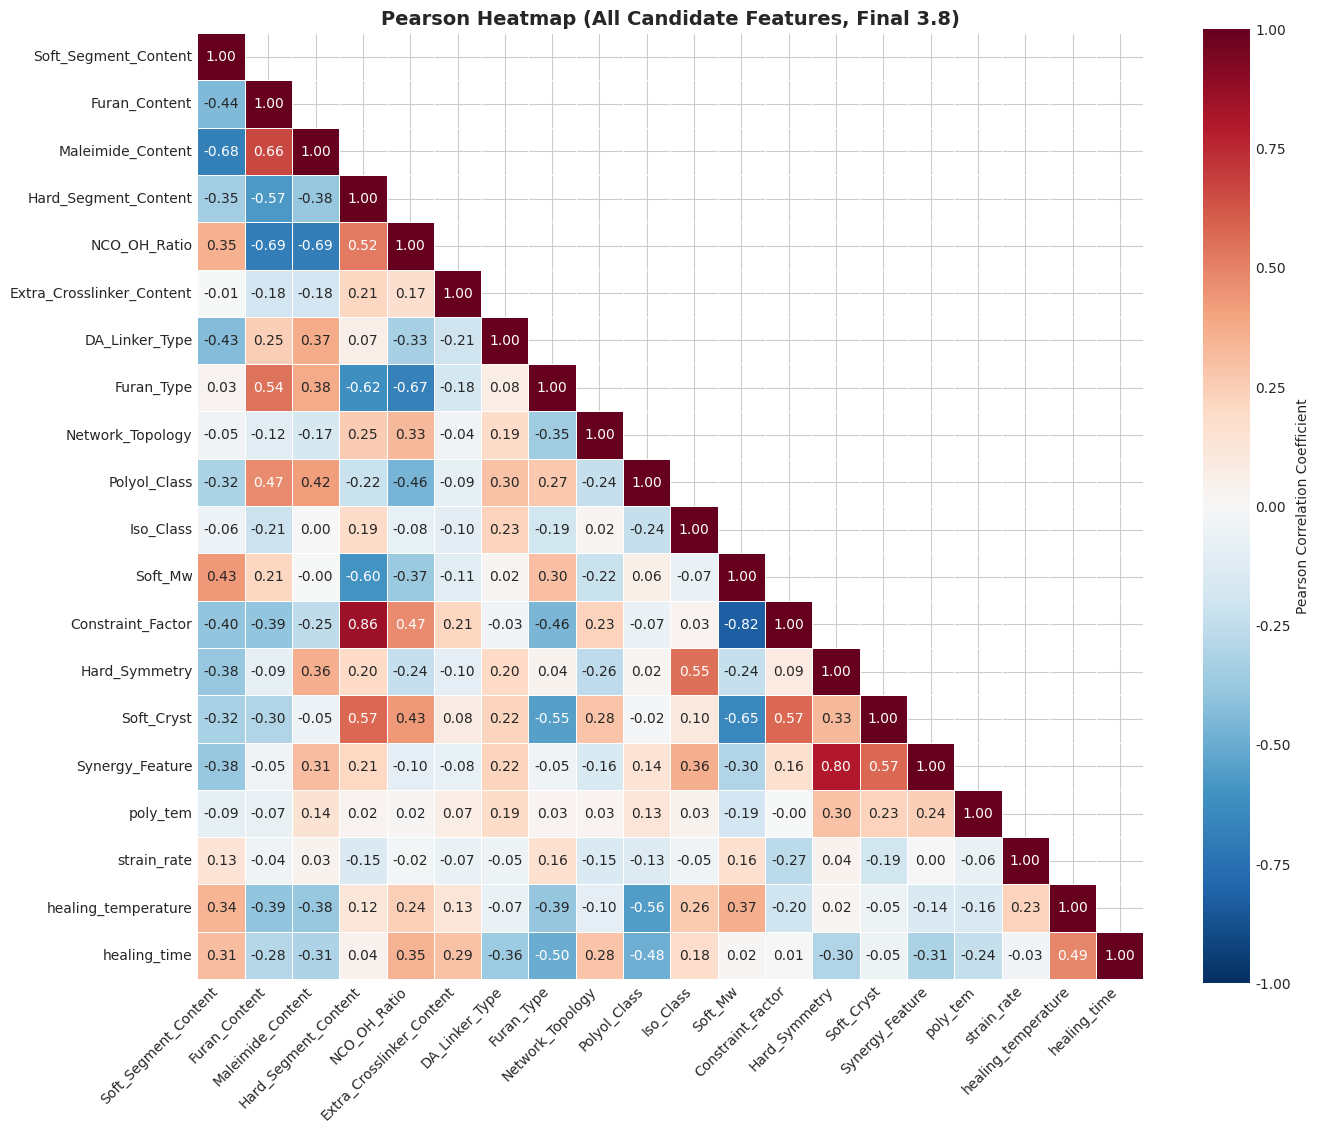


✅ 已保存热力图: Final_3.8_All_Features_Pearson.png


In [19]:
fig_width = max(14, len(feature_cols) * 0.7)
fig_height = max(12, len(feature_cols) * 0.65)

plt.figure(figsize=(fig_width, fig_height))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation Coefficient'}
)
plt.title('Pearson Heatmap (All Candidate Features, Final 3.8)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('Final_3.8_All_Features_Pearson.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✅ 已保存热力图: Final_3.8_All_Features_Pearson.png')

## SVR R² 对比

沿用 `forecast_ML_1.9/alghorithm_multi_1.9_tensile.ipynb` 的 SVR + `GridSearchCV` + `LeaveOneOut` 逻辑，对比原 `1.9` 特征集与当前 `3.8` 特征集在 `tensile_strength` 上的 R² / RMSE 差异。

In [4]:
from pathlib import Path
import json
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, LeaveOneOut, KFold
from sklearn.metrics import r2_score, mean_squared_error

_NB_ROOT = Path.cwd()
if not (_NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv').exists():
    _NB_ROOT = Path.cwd().parent
base_19 = _NB_ROOT / 'forecast_ML_1.9' / 'Final_Features_Ultimate_all_deletion.csv'
base_38 = _NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv'

df_19 = pd.read_csv(base_19)
df_38 = pd.read_csv(base_38)

features_19 = [
    'X1_Soft_Content',
    'X2_DA_Content',
    'X3_Hard_Content',
    'X4_R_Ratio',
    'X5_Add_Crosslink',
    'DA_Linker_Type',
    'Network_Topology',
    'Polyol_Class',
    'Iso_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
]

features_38 = [
    'Soft_Segment_Content',
    'Furan_Content',
    'Maleimide_Content',
    'Hard_Segment_Content',
    'NCO_OH_Ratio',
    'Extra_Crosslinker_Content',
    'DA_Linker_Type',
    'Furan_Type',
    'Network_Topology',
    'Polyol_Class',
    'Iso_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
]

param_grid = {
    'svr__C': [1, 10, 50, 100, 500, 1000],
    'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
    'svr__epsilon': [0.01, 0.1, 0.5],
}
INNER_RANDOM_STATE = 42


def prepare_xy(df_local, feature_cols, target_col='tensile_strength'):
    data = df_local.dropna(subset=[target_col] + feature_cols).copy()
    X = data[feature_cols]
    y = data[target_col]
    return X, y


def _make_inner_cv(n_train: int):
    n_splits = min(5, n_train)
    if n_splits < 2:
        return None
    return KFold(n_splits=n_splits, shuffle=True, random_state=INNER_RANDOM_STATE)


def _aggregate_params(list_of_dicts: list) -> dict:
    serial = [json.dumps(p, sort_keys=True, default=str) for p in list_of_dicts if p]
    if not serial:
        return {}
    return json.loads(Counter(serial).most_common(1)[0][0])


def run_svr_loocv(label, X, y):
    """外层 LOOCV；内层仅在训练折上做 KFold+GridSearch，避免信息泄露。"""
    print('=' * 100)
    print(f'{label} | SVR 嵌套 LOOCV（内层 KFold 调参）')
    print('=' * 100)
    print(f'样本数: {len(y)} | 特征数: {X.shape[1]}')
    loo = LeaveOneOut()
    y_true = y.to_numpy().ravel()
    y_pred = np.zeros_like(y_true, dtype=float)
    fold_params: list = []
    for tr, te in loo.split(X):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr = y.iloc[tr]
        inner = _make_inner_cv(len(tr))
        base = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
        if inner is None:
            m = clone(base)
            m.fit(X_tr, y_tr)
            y_pred[te[0]] = float(m.predict(X_te)[0])
            fold_params.append({})
            continue
        gs = GridSearchCV(
            clone(base),
            param_grid,
            cv=inner,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            verbose=0,
        )
        gs.fit(X_tr, y_tr)
        y_pred[te[0]] = float(gs.predict(X_te)[0])
        fold_params.append(gs.best_params_)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mode_params = _aggregate_params(fold_params)
    print('\n[各折参数众数 | 仅作报告/全数据再训练参考]')
    print(mode_params)
    print(f'R² Score: {r2:.4f}')
    print(f'RMSE: {rmse:.4f}')
    return {
        'Dataset': label,
        'Samples': len(y),
        'Features': X.shape[1],
        'R2': r2,
        'RMSE': rmse,
        'Best_Params': mode_params,
        'y_true': y_true,
        'y_pred': y_pred,
    }

X_19, y_19 = prepare_xy(df_19, features_19)
X_38, y_38 = prepare_xy(df_38, features_38)
result_19 = run_svr_loocv('1.9 原始 tensile 特征集', X_19, y_19)
result_38 = run_svr_loocv('3.8 当前 tensile 特征集', X_38, y_38)
comparison_df = pd.DataFrame([
    {k: v for k, v in result_19.items() if k not in {'Best_Params', 'y_true', 'y_pred'}},
    {k: v for k, v in result_38.items() if k not in {'Best_Params', 'y_true', 'y_pred'}},
])
r2_delta = result_38['R2'] - result_19['R2']
rmse_delta = result_38['RMSE'] - result_19['RMSE']
print('\n' + '=' * 100)
print('SVR 对比汇总')
print('=' * 100)
display(comparison_df)
print(f"R² 差异 (3.8 - 1.9): {r2_delta:+.4f}")
print(f"RMSE 差异 (3.8 - 1.9): {rmse_delta:+.4f}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=120)
axes[0].bar(comparison_df['Dataset'], comparison_df['R2'], color=['#9ecae1', '#F28E2B'], edgecolor='black')
axes[0].set_title('SVR LOOCV R² 对比', fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=15)
for idx, val in enumerate(comparison_df['R2']):
    axes[0].text(idx, val + 0.01, f'{val:.3f}', ha='center', va='bottom')
axes[1].bar(comparison_df['Dataset'], comparison_df['RMSE'], color=['#9ecae1', '#F28E2B'], edgecolor='black')
axes[1].set_title('SVR LOOCV RMSE 对比', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)
for idx, val in enumerate(comparison_df['RMSE']):
    axes[1].text(idx, val + max(comparison_df['RMSE']) * 0.02, f'{val:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


KeyError: ['DA_Linker_Type']

## 3.8 特征消融（SVR）

固定 `SVR + GridSearchCV + LOOCV` 口径，检查以下三个特征是否有保留必要：

- `Constraint_Factor`
- `DA_Linker_Type`
- `Synergy_Feature`

同时测试：

- 基线（全部保留）
- 单独删除 1 个特征
- 三个特征全部删除

Baseline_3.8 | SVR GridSearch + LOOCV
样本数: 84 | 特征数: 16
Fitting 84 folds for each of 108 candidates, totalling 9072 fits

[最佳参数组合]
{'svr__C': 1000, 'svr__epsilon': 0.1, 'svr__gamma': 0.001}
R² Score: 0.7197
RMSE: 7.1199
Remove_Constraint_Factor | SVR GridSearch + LOOCV
样本数: 84 | 特征数: 15
Fitting 84 folds for each of 108 candidates, totalling 9072 fits

[最佳参数组合]
{'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}
R² Score: 0.7330
RMSE: 6.9484
Remove_DA_Linker_Type | SVR GridSearch + LOOCV
样本数: 84 | 特征数: 15
Fitting 84 folds for each of 108 candidates, totalling 9072 fits

[最佳参数组合]
{'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}
R² Score: 0.7581
RMSE: 6.6132
Remove_Synergy_Feature | SVR GridSearch + LOOCV
样本数: 84 | 特征数: 15
Fitting 84 folds for each of 108 candidates, totalling 9072 fits

[最佳参数组合]
{'svr__C': 50, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}
R² Score: 0.7360
RMSE: 6.9100
Remove_All_3 | SVR GridSearch + LOOCV
样本数: 84 | 特征数: 13
Fitting 84 folds for each of 108 cand

,Case,Removed,Feature_Count,R2,RMSE,Delta_R2_vs_Baseline,Delta_RMSE_vs_Baseline
0,Remove_DA_Linker_Type,DA_Linker_Type,15,0.758144,6.613202,0.038484,-0.506729
1,Remove_All_3,"DA_Linker_Type, Constraint_Factor, Synergy_Fea...",13,0.757817,6.617669,0.038157,-0.502263
2,Remove_Synergy_Feature,Synergy_Feature,15,0.735951,6.909962,0.016291,-0.209970
3,Remove_Constraint_Factor,Constraint_Factor,15,0.733007,6.948380,0.013347,-0.171552
4,Baseline_3.8,None,16,0.719660,7.119932,0.000000,0.000000



三个候选特征的保留建议


,Feature,R2_after_remove,RMSE_after_remove,Delta_R2,Delta_RMSE,Decision
0,DA_Linker_Type,0.758144,6.613202,0.038484,-0.506729,建议删除
1,Synergy_Feature,0.735951,6.909962,0.016291,-0.209970,建议删除
2,Constraint_Factor,0.733007,6.948380,0.013347,-0.171552,建议删除


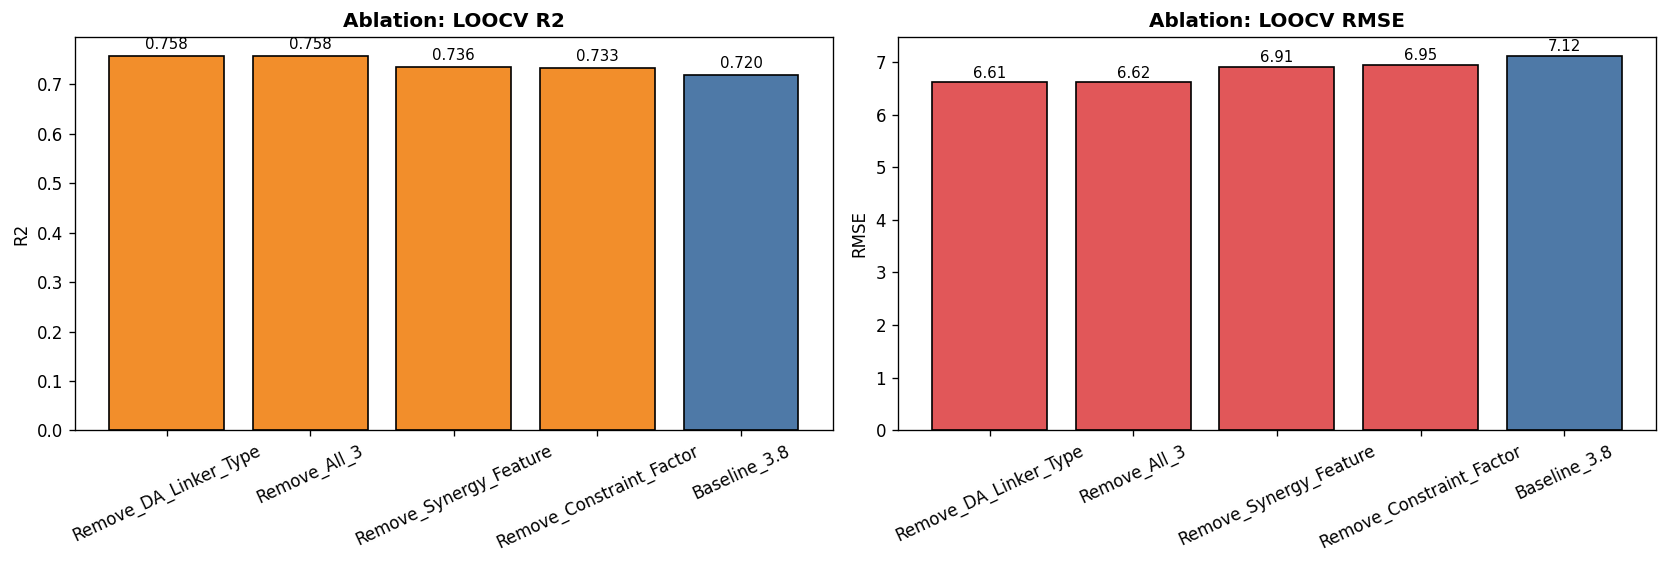

In [2]:
ablation_targets = ['Constraint_Factor', 'DA_Linker_Type', 'Synergy_Feature']

def run_svr_ablation_case(case_name, feature_cols, df_local):
    X_case, y_case = prepare_xy(df_local, feature_cols)
    result = run_svr_loocv(case_name, X_case, y_case)
    return {
        'Case': case_name,
        'Removed': 'None' if len(feature_cols) == len(features_38) else ', '.join([f for f in features_38 if f not in feature_cols]),
        'Feature_Count': len(feature_cols),
        'R2': result['R2'],
        'RMSE': result['RMSE'],
        'Best_Params': result['Best_Params'],
    }

ablation_cases = [('Baseline_3.8', features_38.copy())]
for feature_name in ablation_targets:
    ablation_cases.append((f'Remove_{feature_name}', [col for col in features_38 if col != feature_name]))

ablation_cases.append((
    'Remove_All_3',
    [col for col in features_38 if col not in ablation_targets]
))

ablation_results = []
for case_name, case_features in ablation_cases:
    ablation_results.append(run_svr_ablation_case(case_name, case_features, df_38))

ablation_df = pd.DataFrame(ablation_results)
baseline_row = ablation_df.loc[ablation_df['Case'] == 'Baseline_3.8'].iloc[0]
ablation_df['Delta_R2_vs_Baseline'] = ablation_df['R2'] - baseline_row['R2']
ablation_df['Delta_RMSE_vs_Baseline'] = ablation_df['RMSE'] - baseline_row['RMSE']
ablation_df = ablation_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

def judge_feature_need(delta_r2, delta_rmse, tol_r2=0.01, tol_rmse=0.15):
    if delta_r2 > tol_r2 and delta_rmse < 0:
        return '建议删除'
    if abs(delta_r2) <= tol_r2 and abs(delta_rmse) <= tol_rmse:
        return '可考虑删除'
    return '建议保留'

single_feature_summary = []
for feature_name in ablation_targets:
    row = ablation_df.loc[ablation_df['Case'] == f'Remove_{feature_name}'].iloc[0]
    single_feature_summary.append({
        'Feature': feature_name,
        'R2_after_remove': row['R2'],
        'RMSE_after_remove': row['RMSE'],
        'Delta_R2': row['Delta_R2_vs_Baseline'],
        'Delta_RMSE': row['Delta_RMSE_vs_Baseline'],
        'Decision': judge_feature_need(row['Delta_R2_vs_Baseline'], row['Delta_RMSE_vs_Baseline']),
    })

single_feature_df = pd.DataFrame(single_feature_summary).sort_values(by='Delta_R2', ascending=False).reset_index(drop=True)

print('\n' + '=' * 100)
print('3.8 特征消融结果汇总（SVR + LOOCV）')
print('=' * 100)
display(ablation_df[['Case', 'Removed', 'Feature_Count', 'R2', 'RMSE', 'Delta_R2_vs_Baseline', 'Delta_RMSE_vs_Baseline']])

print('\n' + '=' * 100)
print('三个候选特征的保留建议')
print('=' * 100)
display(single_feature_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), dpi=120)

plot_df = ablation_df.copy()
axes[0].bar(plot_df['Case'], plot_df['R2'], color=['#4E79A7' if case == 'Baseline_3.8' else '#F28E2B' for case in plot_df['Case']], edgecolor='black')
axes[0].set_title('Ablation: LOOCV R2', fontweight='bold')
axes[0].set_ylabel('R2')
axes[0].tick_params(axis='x', rotation=25)
for idx, value in enumerate(plot_df['R2']):
    axes[0].text(idx, value + 0.008, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

axes[1].bar(plot_df['Case'], plot_df['RMSE'], color=['#4E79A7' if case == 'Baseline_3.8' else '#E15759' for case in plot_df['Case']], edgecolor='black')
axes[1].set_title('Ablation: LOOCV RMSE', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=25)
for idx, value in enumerate(plot_df['RMSE']):
    axes[1].text(idx, value + 0.03, f'{value:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 仅删除 `DA_Linker_Type` 后的 8 算法对比

沿用 `forecast_ML_1.9/alghorithm_multi_1.9_tensile.ipynb` 的 8 种算法与动态调参思路，在 `3.8` 特征中**仅删除 `DA_Linker_Type`** 后重跑 `tensile_strength`，比较当前口径下的最优算法。

当前实验：仅删除 DA_Linker_Type
有效样本数: 84
特征数: 15
特征列表:
  - Soft_Segment_Content
  - Furan_Content
  - Maleimide_Content
  - Hard_Segment_Content
  - NCO_OH_Ratio
  - Extra_Crosslinker_Content
  - Furan_Type
  - Network_Topology
  - Polyol_Class
  - Iso_Class
  - Soft_Mw
  - Constraint_Factor
  - Hard_Symmetry
  - Soft_Cryst
  - Synergy_Feature

正在调参与评估: MLR
完成: MLR | R²=-7.5288 | RMSE=39.2715 | Default(NoTune)

正在调参与评估: Ridge
完成: Ridge | R²=0.6524 | RMSE=7.9278 | GridSearch(5组合)

正在调参与评估: LASSO
完成: LASSO | R²=0.6484 | RMSE=7.9733 | GridSearch(5组合)

正在调参与评估: SVR


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

完成: SVR | R²=0.6997 | RMSE=7.3690 | RandomizedSearch(50/210组合)

正在调参与评估: Random Forest
完成: Random Forest | R²=0.6726 | RMSE=7.6941 | RandomizedSearch(50/720组合)

正在调参与评估: XGBoost
完成: XGBoost | R²=0.6814 | RMSE=7.5901 | RandomizedSearch(50/8640组合)

正在调参与评估: GPR


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/yljj0528/Do

完成: GPR | R²=0.7072 | RMSE=7.2765 | GridSearch(54组合)

正在调参与评估: MLP


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

完成: MLP | R²=0.7264 | RMSE=7.0333 | RandomizedSearch(50/320组合)

仅删除 DA_Linker_Type 后的 8 算法结果


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached 

,Model,Route,R2,RMSE,Tune_CV_RMSE
0,MLP,RandomizedSearch(50/320组合),0.726437,7.033343,7.808241
1,GPR,GridSearch(54组合),0.707193,7.276530,7.309467
2,SVR,RandomizedSearch(50/210组合),0.699708,7.368950,7.208018
3,XGBoost,RandomizedSearch(50/8640组合),0.681413,7.590103,8.247873
4,Random Forest,RandomizedSearch(50/720组合),0.672625,7.694076,8.039922
5,Ridge,GridSearch(5组合),0.652434,7.927786,8.615562
6,LASSO,GridSearch(5组合),0.648431,7.973305,8.684763
7,MLR,Default(NoTune),-7.528792,39.271471,6.043029



各模型最优参数:

[MLP] RandomizedSearch(50/320组合)
{'mlpregressor__solver': 'adam', 'mlpregressor__learning_rate_init': 0.0005, 'mlpregressor__hidden_layer_sizes': (32,), 'mlpregressor__alpha': 0.1, 'mlpregressor__activation': 'tanh'}

[GPR] GridSearch(54组合)
{'gaussianprocessregressor__alpha': 0.0001, 'gaussianprocessregressor__kernel': 1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.1), 'gaussianprocessregressor__n_restarts_optimizer': 5, 'gaussianprocessregressor__normalize_y': True}

[SVR] RandomizedSearch(50/210组合)
{'svr__gamma': 'scale', 'svr__epsilon': 0.05, 'svr__C': 100}

[XGBoost] RandomizedSearch(50/8640组合)
{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.6}

[Random Forest] RandomizedSearch(50/720组合)
{'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

[Ridge] GridSearch(5组合)
{'ridge__alpha': 1.0}

[LASSO] GridSearch(5组合)
{'lasso_

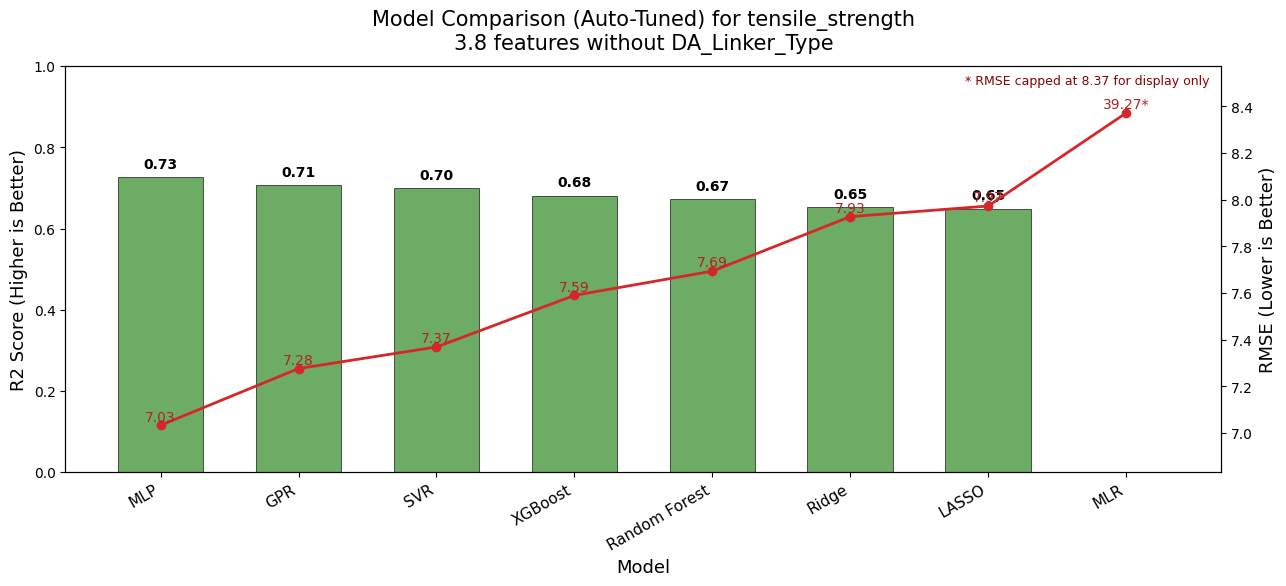

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_predict, GridSearchCV, RandomizedSearchCV, ParameterGrid
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

_NB_ROOT = Path.cwd()
if not (_NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv').exists():
    _NB_ROOT = Path.cwd().parent
file_path_38 = _NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv'
df_model = pd.read_csv(file_path_38)

features_38_drop_da = [
    'Soft_Segment_Content',
    'Furan_Content',
    'Maleimide_Content',
    'Hard_Segment_Content',
    'NCO_OH_Ratio',
    'Extra_Crosslinker_Content',
    'Furan_Type',
    'Network_Topology',
    'Polyol_Class',
    'Iso_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
]

target_col = 'tensile_strength'
data_model = df_model.dropna(subset=[target_col] + features_38_drop_da).copy()
X_model = data_model[features_38_drop_da]
y_model = data_model[target_col]

print('当前实验：仅删除 DA_Linker_Type')
print(f'有效样本数: {len(y_model)}')
print(f'特征数: {len(features_38_drop_da)}')
print('特征列表:')
for feature_name in features_38_drop_da:
    print(f'  - {feature_name}')

TUNE_CV = KFold(n_splits=5, shuffle=True, random_state=42)
GRID_THRESHOLD = 60
RANDOM_ITER = 50

def evaluate_model_loocv(model, X, y):
    """无调参模型使用；有调参模型请用 nested_loocv_search_eval。"""
    y_pred = cross_val_predict(model, X, y, cv=LeaveOneOut(), n_jobs=-1)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    return r2, rmse, y_pred

base_models = {
    'MLR': LinearRegression(),
    'Ridge': make_pipeline(StandardScaler(), Ridge(random_state=42)),
    'LASSO': make_pipeline(StandardScaler(), Lasso(random_state=42, max_iter=20000)),
    'SVR': make_pipeline(StandardScaler(), SVR(kernel='rbf')),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'GPR': make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
            + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            random_state=42
        )
    ),
    'MLP': make_pipeline(StandardScaler(), MLPRegressor(random_state=42, max_iter=5000)),
}

param_spaces = {
    'MLR': {},
    'Ridge': {
        'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    },
    'LASSO': {
        'lasso__alpha': [0.001, 0.005, 0.01, 0.05, 0.1],
    },
    'SVR': {
        'svr__C': [1, 10, 50, 100, 300, 500, 1000],
        'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
        'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    },
    'Random Forest': {
        'n_estimators': [200, 400, 600, 800],
        'max_depth': [None, 10, 20, 30, 40],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 0.7, 1.0],
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.01, 0.02, 0.05, 0.1],
        'max_depth': [3, 4, 5, 6, 8],
        'subsample': [0.6, 0.7, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'reg_alpha': [0.0, 0.1, 1.0],
        'reg_lambda': [1.0, 2.0, 5.0],
    },
    'GPR': {
        'gaussianprocessregressor__kernel': [
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
        ],
        'gaussianprocessregressor__alpha': [1e-10, 1e-6, 1e-4],
        'gaussianprocessregressor__normalize_y': [True, False],
        'gaussianprocessregressor__n_restarts_optimizer': [0, 5, 10],
    },
    'MLP': {
        'mlpregressor__hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64)],
        'mlpregressor__activation': ['relu', 'tanh'],
        'mlpregressor__solver': ['lbfgs', 'adam'],
        'mlpregressor__alpha': [0.0001, 0.001, 0.01, 0.1],
        'mlpregressor__learning_rate_init': [0.0005, 0.001, 0.005, 0.01],
    },
}

def tune_model_with_dynamic_route(model_name, base_model, param_space, X_train, y_train):
    if not param_space:
        base_model.fit(X_train, y_train)
        train_pred = base_model.predict(X_train)
        default_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
        return base_model, 'Default(NoTune)', {}, default_rmse

    total_combinations = len(list(ParameterGrid(param_space)))

    if total_combinations <= GRID_THRESHOLD:
        search = GridSearchCV(
            base_model,
            param_space,
            cv=TUNE_CV,
            scoring='neg_mean_squared_error',
            n_jobs=-1,
        )
        route = f'GridSearch({total_combinations}组合)'
    else:
        n_iter = min(RANDOM_ITER, total_combinations)
        search = RandomizedSearchCV(
            base_model,
            param_space,
            n_iter=n_iter,
            cv=TUNE_CV,
            scoring='neg_mean_squared_error',
            random_state=42,
            n_jobs=-1,
        )
        route = f'RandomizedSearch({n_iter}/{total_combinations}组合)'

    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    best_params = search.best_params_
    best_rmse_cv = np.sqrt(-search.best_score_)
    return best_model, route, best_params, best_rmse_cv

results_8models = []
best_models_8models = {}

for model_name in base_models.keys():
    print('\n' + '=' * 100)
    print(f'正在调参与评估: {model_name}')
    tuned_model, route_used, best_params, tune_rmse, r2, rmse, _ = nested_loocv_search_eval(
        model_name, base_models[model_name], param_spaces[model_name], X_model, y_model
    )
    best_models_8models[model_name] = tuned_model
    results_8models.append({
        'Model': model_name,
        'Route': route_used,
        'R2': r2,
        'RMSE': rmse,
        'Tune_CV_RMSE': tune_rmse,
        'Best_Params': best_params,
    })
    print(f'完成: {model_name} | R²={r2:.4f} | RMSE={rmse:.4f} | {route_used}')

res_df_8models = pd.DataFrame(results_8models).sort_values(by='R2', ascending=False).reset_index(drop=True)

print('\n' + '=' * 100)
print('仅删除 DA_Linker_Type 后的 8 算法结果')
print('=' * 100)
display(res_df_8models[['Model', 'Route', 'R2', 'RMSE', 'Tune_CV_RMSE']])

print('\n各模型最优参数:')
for _, row in res_df_8models.iterrows():
    print(f"\n[{row['Model']}] {row['Route']}")
    print(row['Best_Params'])

best_model_name = res_df_8models.iloc[0]['Model']
best_model_r2 = res_df_8models.iloc[0]['R2']
best_model_rmse = res_df_8models.iloc[0]['RMSE']
print('\n' + '=' * 100)
print(f'当前最优算法: {best_model_name}')
print(f'LOOCV R² = {best_model_r2:.4f}')
print(f'LOOCV RMSE = {best_model_rmse:.4f}')
print('=' * 100)

fig, ax1 = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(res_df_8models))
r2_plot = res_df_8models['R2'].clip(lower=0, upper=1)

ax1.bar(x_pos, r2_plot, alpha=0.88, width=0.62, color='#59A14F', edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Model', fontsize=13)
ax1.set_ylabel('R2 Score (Higher is Better)', fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(res_df_8models['Model'], rotation=30, ha='right', fontsize=11)
for idx, r2_val in enumerate(r2_plot):
    if r2_val > 0:
        ax1.text(idx, min(r2_val + 0.015, 0.985), f'{r2_val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
rmse_raw = res_df_8models['RMSE'].copy()
rmse_cap = rmse_raw.nlargest(2).iloc[-1] * 1.05 if len(rmse_raw) > 1 else rmse_raw.max()
rmse_plot = rmse_raw.clip(upper=rmse_cap)
is_capped = rmse_raw > rmse_cap
ax2.plot(x_pos, rmse_plot, marker='o', linewidth=2.0, linestyle='-', color='#D62728')
ax2.set_ylabel('RMSE (Lower is Better)', fontsize=13)
rmse_min, rmse_max = rmse_plot.min(), rmse_plot.max()
pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
ax2.set_ylim(rmse_min - pad, rmse_max + pad)
for idx, (rmse_disp, rmse_true, capped) in enumerate(zip(rmse_plot, rmse_raw, is_capped)):
    label = f'{rmse_true:.2f}*' if capped else f'{rmse_true:.2f}'
    ax2.text(idx, rmse_disp + (pad * 0.03), label, ha='center', va='bottom', color='#B22222', fontsize=10)

if is_capped.any():
    ax2.text(
        0.99, 0.98,
        f'* RMSE capped at {rmse_cap:.2f} for display only',
        transform=ax2.transAxes, ha='right', va='top', fontsize=9, color='#8B0000'
    )

plt.title('Model Comparison (Auto-Tuned) for tensile_strength\n3.8 features without DA_Linker_Type', fontsize=15, pad=12)
ax1.grid(False)
ax2.grid(False)
fig.tight_layout(pad=1.2)
plt.show()


## 纠正版：仅删除 `DA_Linker_Type` 后的 8 算法严格比较

上一个 8 算法单元使用了 `1.9` 后期 notebook 里的“动态调参近似路线”（`5-fold` / `RandomizedSearch` 优先），因此**不能与前面单独做的 `SVR + LOOCV + GridSearch` 严格结果直接对比**。

这里统一改成：

- 调参：尽量采用 `LOOCV` 精调
- 评估：统一 `LOOCV`
- 数据：仅删除 `DA_Linker_Type`，其余特征保持不变

这样才能和前面 `SVR` 的 `0.758` 口径一致。

严格口径实验：仅删除 DA_Linker_Type
有效样本数: 84
特征数: 15

严格调参与评估: MLR
完成: MLR | R²=-7.5288 | RMSE=39.2715

严格调参与评估: Ridge
  -> 组合数: 5


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

完成: Ridge | R²=0.6535 | RMSE=7.9159

严格调参与评估: LASSO
  -> 组合数: 5
完成: LASSO | R²=0.6484 | RMSE=7.9733

严格调参与评估: SVR
  -> 组合数: 210
完成: SVR | R²=0.7581 | RMSE=6.6132

严格调参与评估: Random Forest
  -> 组合数: 72
完成: Random Forest | R²=0.6795 | RMSE=7.6128

严格调参与评估: XGBoost
  -> 组合数: 432
完成: XGBoost | R²=0.6816 | RMSE=7.5879

严格调参与评估: GPR
  -> 组合数: 54


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn

完成: GPR | R²=0.7119 | RMSE=7.2184

严格调参与评估: MLP
  -> 组合数: 24


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

完成: MLP | R²=0.7286 | RMSE=7.0055

纠正版：仅删除 DA_Linker_Type 后的 8 算法严格结果


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached 

,Model,Route,R2,RMSE,Tune_CV_RMSE
0,SVR,"StrictGridSearch(210组合, LOOCV)",0.758144,6.613202,6.613202
1,MLP,"StrictGridSearch(24组合, LOOCV)",0.728596,7.005533,7.005533
2,GPR,"StrictGridSearch(54组合, LOOCV)",0.711853,7.218387,7.218387
3,XGBoost,"StrictGridSearch(432组合, LOOCV)",0.681597,7.587904,7.587904
4,Random Forest,"StrictGridSearch(72组合, LOOCV)",0.679507,7.612770,7.612770
5,Ridge,"StrictGridSearch(5组合, LOOCV)",0.653475,7.915904,7.915904
6,LASSO,"StrictGridSearch(5组合, LOOCV)",0.648431,7.973305,7.973305
7,MLR,Default(NoTune),-7.528792,39.271471,6.043029



各模型最优参数:

[SVR] StrictGridSearch(210组合, LOOCV)
{'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}

[MLP] StrictGridSearch(24组合, LOOCV)
{'mlpregressor__activation': 'tanh', 'mlpregressor__alpha': 0.01, 'mlpregressor__hidden_layer_sizes': (32,), 'mlpregressor__learning_rate_init': 0.0005, 'mlpregressor__solver': 'adam'}

[GPR] StrictGridSearch(54组合, LOOCV)
{'gaussianprocessregressor__alpha': 1e-10, 'gaussianprocessregressor__kernel': 1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=0.1), 'gaussianprocessregressor__n_restarts_optimizer': 0, 'gaussianprocessregressor__normalize_y': False}

[XGBoost] StrictGridSearch(432组合, LOOCV)
{'colsample_bytree': 0.6, 'learning_rate': 0.02, 'max_depth': 6, 'n_estimators': 300, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'subsample': 1.0}

[Random Forest] StrictGridSearch(72组合, LOOCV)
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

[Ridge] StrictGridSearch(5组合, LOOCV)
{'ridge

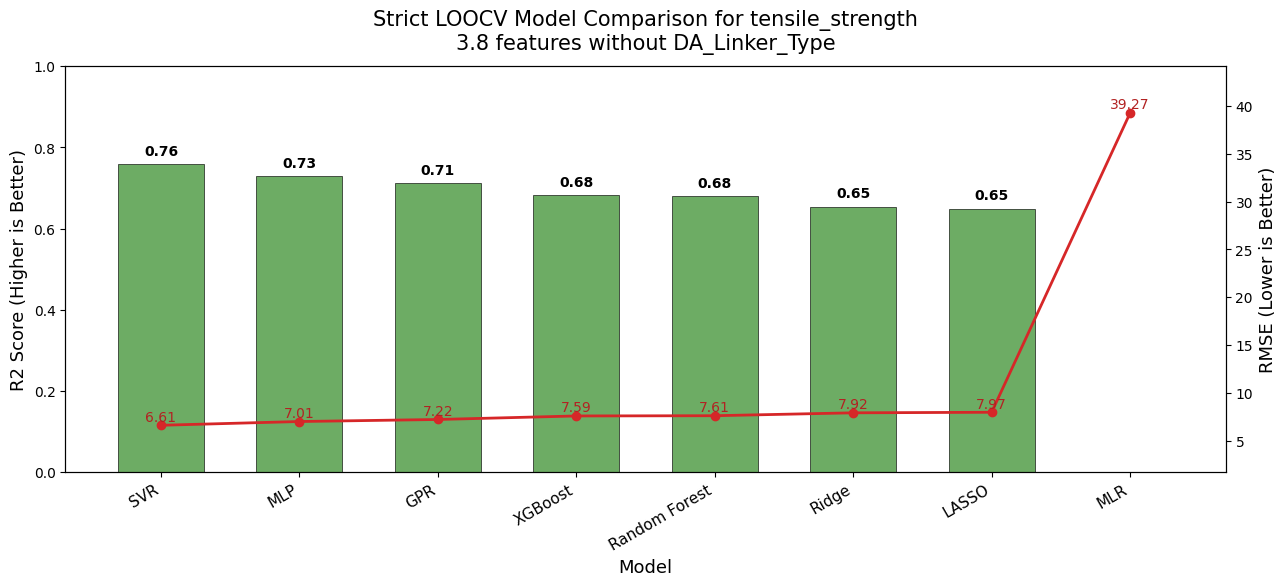

In [2]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.model_selection import LeaveOneOut, cross_val_predict, GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

_NB_ROOT = Path.cwd()
if not (_NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv').exists():
    _NB_ROOT = Path.cwd().parent
file_path_strict = _NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv'
df_strict = pd.read_csv(file_path_strict)

features_strict = [
    'Soft_Segment_Content',
    'Furan_Content',
    'Maleimide_Content',
    'Hard_Segment_Content',
    'NCO_OH_Ratio',
    'Extra_Crosslinker_Content',
    'Furan_Type',
    'Network_Topology',
    'Polyol_Class',
    'Iso_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
]

target_col = 'tensile_strength'
data_strict = df_strict.dropna(subset=[target_col] + features_strict).copy()
X_strict = data_strict[features_strict]
y_strict = data_strict[target_col]

print('严格口径实验：仅删除 DA_Linker_Type')
print(f'有效样本数: {len(y_strict)}')
print(f'特征数: {len(features_strict)}')

strict_cv = LeaveOneOut()

def evaluate_loocv(model, X, y):
    y_pred = cross_val_predict(model, X, y, cv=strict_cv, n_jobs=-1)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    return r2, rmse, y_pred

strict_models = {
    'MLR': LinearRegression(),
    'Ridge': make_pipeline(StandardScaler(), Ridge(random_state=42)),
    'LASSO': make_pipeline(StandardScaler(), Lasso(random_state=42, max_iter=20000)),
    'SVR': make_pipeline(StandardScaler(), SVR(kernel='rbf')),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=1),
    'GPR': make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
            + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            random_state=42
        )
    ),
    'MLP': make_pipeline(StandardScaler(), MLPRegressor(random_state=42, max_iter=5000)),
}

strict_param_spaces = {
    'MLR': {},
    'Ridge': {
        'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    },
    'LASSO': {
        'lasso__alpha': [0.001, 0.005, 0.01, 0.05, 0.1],
    },
    'SVR': {
        'svr__C': [1, 10, 50, 100, 300, 500, 1000],
        'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
        'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    },
    'Random Forest': {
        'n_estimators': [300, 600, 800],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 0.7],
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'learning_rate': [0.02, 0.05],
        'max_depth': [3, 4, 6],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8],
        'reg_alpha': [0.0, 1.0],
        'reg_lambda': [1.0, 5.0],
    },
    'GPR': {
        'gaussianprocessregressor__kernel': [
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
        ],
        'gaussianprocessregressor__alpha': [1e-10, 1e-6, 1e-4],
        'gaussianprocessregressor__normalize_y': [True, False],
        'gaussianprocessregressor__n_restarts_optimizer': [0, 5, 10],
    },
    'MLP': {
        'mlpregressor__hidden_layer_sizes': [(32,), (64,), (64, 32)],
        'mlpregressor__activation': ['tanh'],
        'mlpregressor__solver': ['lbfgs', 'adam'],
        'mlpregressor__alpha': [0.01, 0.1],
        'mlpregressor__learning_rate_init': [0.0005, 0.001],
    },
}

def strict_tune_model(model_name, model, param_space, X, y):
    import json as _j
    from collections import Counter as _C
    if not param_space:
        r2, rmse, _ = evaluate_loocv(model, X, y)
        model.fit(X, y)
        train_rmse = np.sqrt(mean_squared_error(y, model.predict(X)))
        return model, 'Default(NoTune)', {}, train_rmse, r2, rmse
    total_combinations = 1
    for values in param_space.values():
        total_combinations *= len(values)
    print(f'  -> 组合数: {total_combinations} (内层 KFold 调参)')
    yv = np.asarray(y).ravel()
    y_pred = np.zeros(len(yv))
    inner_scores = []
    fold_params: list = []
    Xdf = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    yser = pd.Series(yv)
    for tr, te in strict_cv.split(Xdf):
        X_tr, X_te = Xdf.iloc[tr], Xdf.iloc[te]
        y_tr = yser.iloc[tr]
        nn = len(tr)
        ns = min(5, nn)
        inner = KFold(n_splits=ns, shuffle=True, random_state=42) if ns >= 2 else None
        est = clone(model)
        if inner is None:
            est.fit(X_tr, y_tr)
            y_pred[te[0]] = float(est.predict(X_te)[0])
            fold_params.append({})
            continue
        search = GridSearchCV(
            est, param_space, cv=inner, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0,
        )
        search.fit(X_tr, y_tr)
        y_pred[te[0]] = float(search.predict(X_te)[0])
        inner_scores.append(float(np.sqrt(-search.best_score_)))
        fold_params.append(search.best_params_)
    r2 = r2_score(yv, y_pred)
    rmse = np.sqrt(mean_squared_error(yv, y_pred))
    tune_rmse = float(np.mean(inner_scores)) if inner_scores else np.nan
    keys = [_j.dumps(p, sort_keys=True, default=str) for p in fold_params if p]
    maj = _j.loads(_C(keys).most_common(1)[0][0]) if keys else {}
    final_m = clone(model)
    if maj:
        final_m.set_params(**maj)
    final_m.fit(Xdf, yser)
    route = f'StrictNestedGrid({total_combinations}组合)'
    return final_m, route, maj, tune_rmse, r2, rmse

strict_results = []
strict_best_models = {}

for model_name, model in strict_models.items():
    print('\n' + '=' * 100)
    print(f'严格调参与评估: {model_name}')
    tuned_model, route_used, best_params, tune_rmse, r2, rmse = strict_tune_model(
        model_name, model, strict_param_spaces[model_name], X_strict, y_strict
    )
    strict_best_models[model_name] = tuned_model
    strict_results.append({
        'Model': model_name,
        'Route': route_used,
        'R2': r2,
        'RMSE': rmse,
        'Tune_CV_RMSE': tune_rmse,
        'Best_Params': best_params,
    })
    print(f'完成: {model_name} | R²={r2:.4f} | RMSE={rmse:.4f}')

strict_df = pd.DataFrame(strict_results).sort_values(by='R2', ascending=False).reset_index(drop=True)

print('\n' + '=' * 100)
print('纠正版：仅删除 DA_Linker_Type 后的 8 算法严格结果')
print('=' * 100)
display(strict_df[['Model', 'Route', 'R2', 'RMSE', 'Tune_CV_RMSE']])

print('\n各模型最优参数:')
for _, row in strict_df.iterrows():
    print(f"\n[{row['Model']}] {row['Route']}")
    print(row['Best_Params'])

strict_best_name = strict_df.iloc[0]['Model']
strict_best_r2 = strict_df.iloc[0]['R2']
strict_best_rmse = strict_df.iloc[0]['RMSE']
print('\n' + '=' * 100)
print(f'纠正版当前最优算法: {strict_best_name}')
print(f'LOOCV R² = {strict_best_r2:.4f}')
print(f'LOOCV RMSE = {strict_best_rmse:.4f}')
print('=' * 100)

fig, ax1 = plt.subplots(figsize=(13, 6))
x_pos = np.arange(len(strict_df))
r2_plot = strict_df['R2'].clip(lower=0, upper=1)

ax1.bar(x_pos, r2_plot, alpha=0.88, width=0.62, color='#59A14F', edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Model', fontsize=13)
ax1.set_ylabel('R2 Score (Higher is Better)', fontsize=13)
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(strict_df['Model'], rotation=30, ha='right', fontsize=11)
for idx, r2_val in enumerate(r2_plot):
    if r2_val > 0:
        ax1.text(idx, min(r2_val + 0.015, 0.985), f'{r2_val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
rmse_plot = strict_df['RMSE']
ax2.plot(x_pos, rmse_plot, marker='o', linewidth=2.0, linestyle='-', color='#D62728')
ax2.set_ylabel('RMSE (Lower is Better)', fontsize=13)
rmse_min, rmse_max = rmse_plot.min(), rmse_plot.max()
pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
ax2.set_ylim(rmse_min - pad, rmse_max + pad)
for idx, rmse_val in enumerate(rmse_plot):
    ax2.text(idx, rmse_val + (pad * 0.03), f'{rmse_val:.2f}', ha='center', va='bottom', color='#B22222', fontsize=10)

plt.title('Strict LOOCV Model Comparison for tensile_strength\n3.8 features without DA_Linker_Type', fontsize=15, pad=12)
ax1.grid(False)
ax2.grid(False)
fig.tight_layout(pad=1.2)
plt.show()


## 系统化特征消融（SVR）

这里采用两阶段方案，兼顾系统性和严格性：

1. 以当前 `3.8` 数据集（已永久删除 `DA_Linker_Type`）为基线；
2. 对每个建模特征做一次单特征删除（leave-one-feature-out）；
3. 第一阶段使用围绕当前最优 `SVR` 参数的聚焦网格做快速筛查；
4. 第二阶段对筛查后最有希望提升的候选，再用完整严格 `LOOCV + GridSearch` 复核。

这样可以回答两个问题：
- 哪些特征删除后 **明显提升**；
- 哪些特征虽然看起来一般，但在严格复核后其实 **不应该删除**。

阶段 0：重新建立当前 15 特征基线（严格 LOOCV）
基线 R² = 0.7581, RMSE = 6.6132
基线参数 = {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}

阶段 1：单特征删除快速筛查（聚焦网格 + LOOCV）
[01/15] 删除 Soft_Segment_Content: R²=0.7640, ΔR²=+0.0058
[02/15] 删除 Furan_Content: R²=0.7627, ΔR²=+0.0045
[03/15] 删除 Maleimide_Content: R²=0.7615, ΔR²=+0.0033
[04/15] 删除 Hard_Segment_Content: R²=0.7582, ΔR²=+0.0000
[05/15] 删除 NCO_OH_Ratio: R²=0.7751, ΔR²=+0.0170
[06/15] 删除 Extra_Crosslinker_Content: R²=0.7556, ΔR²=-0.0026
[07/15] 删除 Furan_Type: R²=0.8014, ΔR²=+0.0432
[08/15] 删除 Network_Topology: R²=0.7899, ΔR²=+0.0317
[09/15] 删除 Polyol_Class: R²=0.7463, ΔR²=-0.0118
[10/15] 删除 Iso_Class: R²=0.7058, ΔR²=-0.0523
[11/15] 删除 Soft_Mw: R²=0.7341, ΔR²=-0.0240
[12/15] 删除 Constraint_Factor: R²=0.7686, ΔR²=+0.0104
[13/15] 删除 Hard_Symmetry: R²=0.7534, ΔR²=-0.0047
[14/15] 删除 Soft_Cryst: R²=0.6965, ΔR²=-0.0617
[15/15] 删除 Synergy_Feature: R²=0.7460, ΔR²=-0.0122


,Removed_Feature,R2,RMSE,Delta_R2_vs_Baseline,Delta_RMSE_vs_Baseline
0,Furan_Type,0.801385,5.992933,0.043241,-0.620269
1,Network_Topology,0.789889,6.163933,0.031745,-0.449270
2,NCO_OH_Ratio,0.775113,6.376994,0.016969,-0.236208
3,Constraint_Factor,0.768566,6.469150,0.010422,-0.144052
4,Soft_Segment_Content,0.763984,6.532876,0.005840,-0.080327
5,Furan_Content,0.762672,6.551005,0.004528,-0.062198
6,Maleimide_Content,0.761484,6.567384,0.003340,-0.045818
7,Hard_Segment_Content,0.758155,6.613049,0.000011,-0.000154
8,Extra_Crosslinker_Content,0.755585,6.648097,-0.002559,0.034894
9,Hard_Symmetry,0.753442,6.677181,-0.004702,0.063979



阶段 2：对前 5 个候选做完整严格复核（完整网格 + LOOCV）
候选特征: ['Furan_Type', 'Network_Topology', 'NCO_OH_Ratio', 'Constraint_Factor', 'Soft_Segment_Content']
[复核 1/5] 删除 Furan_Type: R²=0.8014, RMSE=5.9929, ΔR²=+0.0432
[复核 2/5] 删除 Network_Topology: R²=0.7856, RMSE=6.2265, ΔR²=+0.0275
[复核 3/5] 删除 NCO_OH_Ratio: R²=0.7751, RMSE=6.3770, ΔR²=+0.0170
[复核 4/5] 删除 Constraint_Factor: R²=0.7686, RMSE=6.4692, ΔR²=+0.0104
[复核 5/5] 删除 Soft_Segment_Content: R²=0.7586, RMSE=6.6063, ΔR²=+0.0005


,Removed_Feature,R2,RMSE,Delta_R2_vs_Baseline,Delta_RMSE_vs_Baseline
0,Furan_Type,0.801385,5.992933,0.043241,-0.620269
1,Network_Topology,0.785600,6.226529,0.027456,-0.386673
2,NCO_OH_Ratio,0.775113,6.376994,0.016969,-0.236208
3,Constraint_Factor,0.768566,6.469150,0.010422,-0.144052
4,Soft_Segment_Content,0.758645,6.606344,0.000501,-0.006858



系统化消融结论
当前基线（15 特征）: R²=0.7581, RMSE=6.6132

建议优先考虑删除的特征（严格复核后仍提升）:
- Furan_Type: R²=0.8014, ΔR²=+0.0432, RMSE=5.9929
- Network_Topology: R²=0.7856, ΔR²=+0.0275, RMSE=6.2265
- NCO_OH_Ratio: R²=0.7751, ΔR²=+0.0170, RMSE=6.3770
- Constraint_Factor: R²=0.7686, ΔR²=+0.0104, RMSE=6.4692
- Soft_Segment_Content: R²=0.7586, ΔR²=+0.0005, RMSE=6.6063


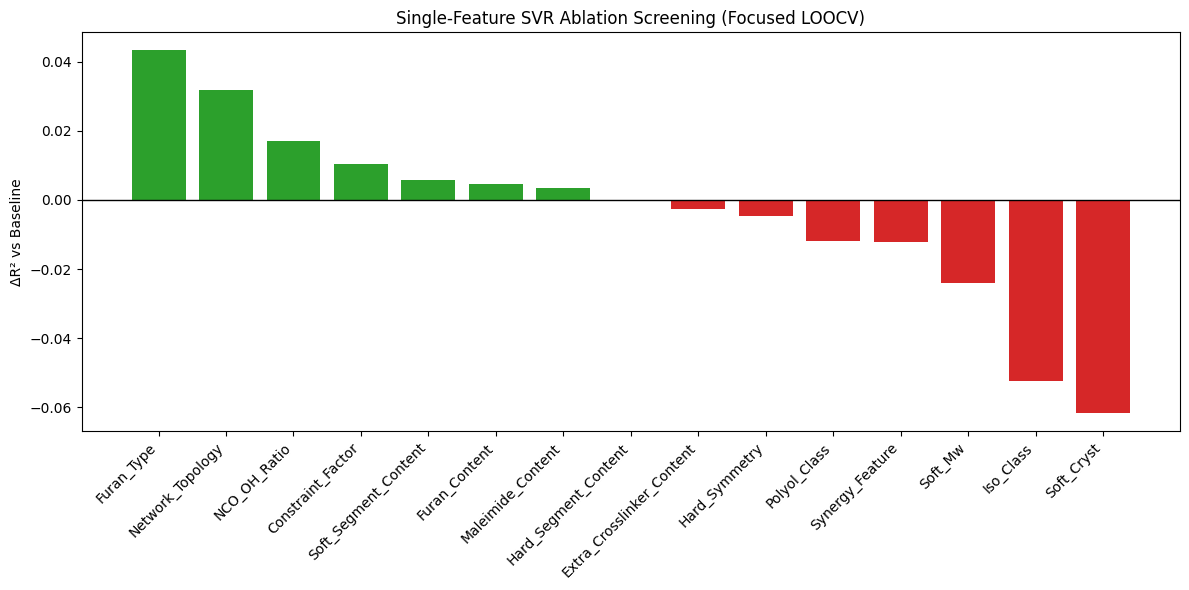

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.svm import SVR

_NB_ROOT = Path.cwd()
if not (_NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv').exists():
    _NB_ROOT = Path.cwd().parent
ablation_file = _NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv'
ablation_df = pd.read_csv(ablation_file)

ablation_features = [
    'Soft_Segment_Content',
    'Furan_Content',
    'Maleimide_Content',
    'Hard_Segment_Content',
    'NCO_OH_Ratio',
    'Extra_Crosslinker_Content',
    'Furan_Type',
    'Network_Topology',
    'Polyol_Class',
    'Iso_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
]
ablation_target = 'tensile_strength'

ablation_data = ablation_df.dropna(subset=[ablation_target] + ablation_features).copy()
X_full = ablation_data[ablation_features]
y_full = ablation_data[ablation_target]
loo = LeaveOneOut()

focused_grid = {
    'svr__C': [50, 100, 300],
    'svr__gamma': [0.005, 0.01, 0.05],
    'svr__epsilon': [0.01, 0.05, 0.1],
}

full_grid = {
    'svr__C': [1, 10, 50, 100, 300, 500, 1000],
    'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
    'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
}

def tune_and_eval_svr(X, y, param_grid):
    yv = np.asarray(y).ravel()
    y_pred = np.zeros(len(yv))
    fold_best = []
    Xdf = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    yser = pd.Series(yv)
    for tr, te in loo.split(Xdf):
        X_tr, X_te = Xdf.iloc[tr], Xdf.iloc[te]
        y_tr = yser.iloc[tr]
        nn = len(tr)
        ns = min(5, nn)
        inner = KFold(n_splits=ns, shuffle=True, random_state=42) if ns >= 2 else None
        base = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
        if inner is None:
            m = clone(base)
            m.fit(X_tr, y_tr)
            y_pred[te[0]] = float(m.predict(X_te)[0])
            fold_best.append({})
            continue
        search = GridSearchCV(
            clone(base), param_grid, cv=inner, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0,
        )
        search.fit(X_tr, y_tr)
        y_pred[te[0]] = float(search.predict(X_te)[0])
        fold_best.append(search.best_params_)
    r2 = r2_score(yv, y_pred)
    rmse = np.sqrt(mean_squared_error(yv, y_pred))
    import json as _j
    from collections import Counter as _C
    keys = [_j.dumps(p, sort_keys=True, default=str) for p in fold_best if p]
    maj = _j.loads(_C(keys).most_common(1)[0][0]) if keys else {}
    best_model = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
    if maj:
        best_model.set_params(**maj)
    best_model.fit(Xdf, yser)
    return {'best_model': best_model, 'best_params': maj, 'r2': r2, 'rmse': rmse}

print('阶段 0：重新建立当前 15 特征基线（严格 LOOCV）')
baseline = tune_and_eval_svr(X_full, y_full, full_grid)
print(f"基线 R² = {baseline['r2']:.4f}, RMSE = {baseline['rmse']:.4f}")
print(f"基线参数 = {baseline['best_params']}")

screen_results = []
print('\n阶段 1：单特征删除快速筛查（聚焦网格 + LOOCV）')
for idx, feature in enumerate(ablation_features, start=1):
    subset = [col for col in ablation_features if col != feature]
    result = tune_and_eval_svr(ablation_data[subset], y_full, focused_grid)
    screen_results.append({
        'Removed_Feature': feature,
        'Stage': 'FocusedScreen',
        'Num_Features': len(subset),
        'R2': result['r2'],
        'RMSE': result['rmse'],
        'Delta_R2_vs_Baseline': result['r2'] - baseline['r2'],
        'Delta_RMSE_vs_Baseline': result['rmse'] - baseline['rmse'],
        'Best_Params': result['best_params'],
    })
    print(f"[{idx:02d}/{len(ablation_features)}] 删除 {feature}: R²={result['r2']:.4f}, ΔR²={result['r2'] - baseline['r2']:+.4f}")

screen_df = pd.DataFrame(screen_results).sort_values(by='Delta_R2_vs_Baseline', ascending=False).reset_index(drop=True)
display(screen_df[['Removed_Feature', 'R2', 'RMSE', 'Delta_R2_vs_Baseline', 'Delta_RMSE_vs_Baseline']])

top_candidates = screen_df.head(5)['Removed_Feature'].tolist()
print('\n阶段 2：对前 5 个候选做完整严格复核（完整网格 + LOOCV）')
print('候选特征:', top_candidates)

strict_recheck = []
for idx, feature in enumerate(top_candidates, start=1):
    subset = [col for col in ablation_features if col != feature]
    result = tune_and_eval_svr(ablation_data[subset], y_full, full_grid)
    strict_recheck.append({
        'Removed_Feature': feature,
        'Stage': 'StrictRecheck',
        'Num_Features': len(subset),
        'R2': result['r2'],
        'RMSE': result['rmse'],
        'Delta_R2_vs_Baseline': result['r2'] - baseline['r2'],
        'Delta_RMSE_vs_Baseline': result['rmse'] - baseline['rmse'],
        'Best_Params': result['best_params'],
    })
    print(f"[复核 {idx}/{len(top_candidates)}] 删除 {feature}: R²={result['r2']:.4f}, RMSE={result['rmse']:.4f}, ΔR²={result['r2'] - baseline['r2']:+.4f}")

strict_df_ablation = pd.DataFrame(strict_recheck).sort_values(by='Delta_R2_vs_Baseline', ascending=False).reset_index(drop=True)
display(strict_df_ablation[['Removed_Feature', 'R2', 'RMSE', 'Delta_R2_vs_Baseline', 'Delta_RMSE_vs_Baseline']])

recommended_to_remove = strict_df_ablation[strict_df_ablation['Delta_R2_vs_Baseline'] > 0].copy()
recommended_to_keep = strict_df_ablation[strict_df_ablation['Delta_R2_vs_Baseline'] <= 0].copy()

print('\n系统化消融结论')
print('=' * 90)
print(f"当前基线（15 特征）: R²={baseline['r2']:.4f}, RMSE={baseline['rmse']:.4f}")

if not recommended_to_remove.empty:
    print('\n建议优先考虑删除的特征（严格复核后仍提升）:')
    for _, row in recommended_to_remove.iterrows():
        print(f"- {row['Removed_Feature']}: R²={row['R2']:.4f}, ΔR²={row['Delta_R2_vs_Baseline']:+.4f}, RMSE={row['RMSE']:.4f}")
else:
    print('\n本轮严格复核后，没有特征在单独删除时能稳定优于当前基线。')

if not recommended_to_keep.empty:
    print('\n不建议删除的候选（筛查看似有利，但严格复核不成立）:')
    for _, row in recommended_to_keep.iterrows():
        print(f"- {row['Removed_Feature']}: R²={row['R2']:.4f}, ΔR²={row['Delta_R2_vs_Baseline']:+.4f}, RMSE={row['RMSE']:.4f}")

plot_df = screen_df.copy()
plot_df['Color'] = np.where(plot_df['Delta_R2_vs_Baseline'] > 0, '#2ca02c', '#d62728')

plt.figure(figsize=(12, 6))
plt.bar(plot_df['Removed_Feature'], plot_df['Delta_R2_vs_Baseline'], color=plot_df['Color'])
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel('ΔR² vs Baseline')
plt.title('Single-Feature SVR Ablation Screening (Focused LOOCV)')
plt.tight_layout()
plt.show()


## `Furan_Type` 独热编码对比（多目标）

为了兼顾“预测性能”和“最终配方可解释性”，这里不直接删除 `Furan_Type`，而是比较三种处理方式：

1. 保留整数编码（当前做法）
2. 改成独热编码（One-Hot）
3. 从训练特征中删除（仅作参考）

并分别在以下目标上做严格 `SVR + LOOCV + GridSearch` 对比：

- `tensile_strength`
- `elongation`
- `healing_eff`

这样可以回答：
- `Furan_Type` 是否对某个目标真的有用；
- 如果有用，是“信息本身有用”，还是“整数编码方式有问题”。

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.svm import SVR

_NB_ROOT = Path.cwd()
if not (_NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv').exists():
    _NB_ROOT = Path.cwd().parent
compare_file = _NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv'
compare_df = pd.read_csv(compare_file)

base_structural_features = [
    'Soft_Segment_Content',
    'Furan_Content',
    'Maleimide_Content',
    'Hard_Segment_Content',
    'NCO_OH_Ratio',
    'Extra_Crosslinker_Content',
    'Furan_Type',
    'Network_Topology',
    'Polyol_Class',
    'Iso_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
]

target_feature_map = {
    'tensile_strength': base_structural_features.copy(),
    'elongation': base_structural_features.copy(),
    'healing_eff': base_structural_features + ['healing_temperature', 'healing_time'],
}

encoding_grid = {
    'svr__C': [1, 10, 50, 100, 300, 500, 1000],
    'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
    'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
}

encoding_loo = LeaveOneOut()

def build_encoding_dataset(df_local, feature_cols, target_col, mode):
    data = df_local.dropna(subset=[target_col] + feature_cols).copy()
    X = data[feature_cols].copy()
    y = data[target_col].copy()

    if mode == 'ordinal':
        return X, y

    if mode == 'drop':
        X = X.drop(columns=['Furan_Type'])
        return X, y

    if mode == 'onehot':
        furan_dummies = pd.get_dummies(X['Furan_Type'].astype(int), prefix='Furan_Type', dtype=float)
        X = pd.concat([X.drop(columns=['Furan_Type']), furan_dummies], axis=1)
        return X, y

    raise ValueError(f'Unknown mode: {mode}')

def run_encoding_svr(X, y):
    yv = np.asarray(y).ravel()
    y_pred = np.zeros(len(yv))
    fold_best = []
    Xdf = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    yser = pd.Series(yv)
    for tr, te in encoding_loo.split(Xdf):
        X_tr, X_te = Xdf.iloc[tr], Xdf.iloc[te]
        y_tr = yser.iloc[tr]
        nn = len(tr)
        ns = min(5, nn)
        inner = KFold(n_splits=ns, shuffle=True, random_state=42) if ns >= 2 else None
        base = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
        if inner is None:
            m = clone(base)
            m.fit(X_tr, y_tr)
            y_pred[te[0]] = float(m.predict(X_te)[0])
            fold_best.append({})
            continue
        search = GridSearchCV(
            clone(base), encoding_grid, cv=inner, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0,
        )
        search.fit(X_tr, y_tr)
        y_pred[te[0]] = float(search.predict(X_te)[0])
        fold_best.append(search.best_params_)
    r2 = r2_score(yv, y_pred)
    rmse = np.sqrt(mean_squared_error(yv, y_pred))
    import json as _j
    from collections import Counter as _C
    keys = [_j.dumps(p, sort_keys=True, default=str) for p in fold_best if p]
    maj = _j.loads(_C(keys).most_common(1)[0][0]) if keys else {}
    return {'R2': r2, 'RMSE': rmse, 'Best_Params': maj, 'Feature_Count': X.shape[1]}

mode_name_map = {
    'ordinal': '整数编码',
    'onehot': '独热编码',
    'drop': '删除该特征',
}

encoding_results = []

for target_name, feature_list in target_feature_map.items():
    print('\n' + '=' * 100)
    print(f'目标: {target_name}')
    print('=' * 100)
    for mode in ['ordinal', 'onehot', 'drop']:
        X_cur, y_cur = build_encoding_dataset(compare_df, feature_list, target_name, mode)
        result = run_encoding_svr(X_cur, y_cur)
        encoding_results.append({
            'Target': target_name,
            'Furan_Type_Mode': mode_name_map[mode],
            'Mode_Key': mode,
            'Feature_Count': result['Feature_Count'],
            'Samples': len(y_cur),
            'R2': result['R2'],
            'RMSE': result['RMSE'],
            'Best_Params': result['Best_Params'],
        })
        print(
            f"- {mode_name_map[mode]}: 样本={len(y_cur)}, 特征数={result['Feature_Count']}, "
            f"R²={result['R2']:.4f}, RMSE={result['RMSE']:.4f}"
        )

encoding_result_df = pd.DataFrame(encoding_results)
encoding_result_df = encoding_result_df.sort_values(by=['Target', 'R2'], ascending=[True, False]).reset_index(drop=True)

print('\n' + '=' * 100)
print('`Furan_Type` 编码方式对比汇总')
print('=' * 100)
display(encoding_result_df[['Target', 'Furan_Type_Mode', 'Feature_Count', 'Samples', 'R2', 'RMSE']])

best_by_target = encoding_result_df.groupby('Target', as_index=False).first()
print('\n各目标当前最优的 `Furan_Type` 处理方式:')
display(best_by_target[['Target', 'Furan_Type_Mode', 'R2', 'RMSE']])

for target_name in best_by_target['Target']:
    subset = encoding_result_df[encoding_result_df['Target'] == target_name].copy()
    baseline_row = subset[subset['Mode_Key'] == 'ordinal'].iloc[0]
    print(f"\n目标 `{target_name}` 相对整数编码的变化：")
    for _, row in subset.iterrows():
        delta_r2 = row['R2'] - baseline_row['R2']
        delta_rmse = row['RMSE'] - baseline_row['RMSE']
        print(
            f"- {row['Furan_Type_Mode']}: ΔR²={delta_r2:+.4f}, ΔRMSE={delta_rmse:+.4f}"
        )

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), dpi=120)
target_order = ['tensile_strength', 'elongation', 'healing_eff']

for idx, target_name in enumerate(target_order):
    subset = encoding_result_df[encoding_result_df['Target'] == target_name].copy()
    subset = subset.sort_values(by='R2', ascending=False)
    axes[idx].bar(subset['Furan_Type_Mode'], subset['R2'], color=['#4E79A7', '#59A14F', '#F28E2B'])
    axes[idx].set_title(target_name, fontweight='bold')
    axes[idx].set_ylabel('R²')
    axes[idx].tick_params(axis='x', rotation=20)
    for bar_idx, val in enumerate(subset['R2']):
        axes[idx].text(bar_idx, val + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()



目标: tensile_strength
- 整数编码: 样本=84, 特征数=15, R²=0.6722, RMSE=7.6986


KeyboardInterrupt: 

## 复刻 `1.9` 的多模型选择逻辑到 `3.8` 新特征

这里不再用前面的严格网格搜索口径，而是**严格复刻**你在 `alghorithm_multi_1.9_elongation.ipynb` 和 `alghorithm_multi_1.9_healing.ipynb` 里的多模型横向对比思路：

- 固定一组你原来用过的模型超参数；
- 使用同样的 `LOOCV` 评估方式；
- 对 `tensile_strength`、`elongation`、`healing_eff` 分别比较模型；
- 在 `3.8` 新特征下保留 `Furan_Type`，不删除。

这样得到的结果，才和你过去 notebook 里的“多模型选择结果”处于同一口径。


复刻旧版多模型选择 | 目标: tensile_strength
样本数: 84 | 特征数: 17
 -> Random Forest: R²=0.6043, RMSE=8.4589
 -> XGBoost: R²=0.6094, RMSE=8.4043
 -> SVR: R²=0.6152, RMSE=8.3412
 -> GPR: R²=0.6951, RMSE=7.4258


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

 -> ANN (MLP): R²=0.5170, RMSE=9.3455
 -> KRR: R²=0.6970, RMSE=7.4023


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/

,Target,Model,R2,RMSE,Samples,Feature_Count
0,tensile_strength,KRR,0.696985,7.402276,84,17
1,tensile_strength,GPR,0.695055,7.425815,84,17
2,tensile_strength,SVR,0.615235,8.341247,84,17
3,tensile_strength,XGBoost,0.609395,8.404313,84,17
4,tensile_strength,Random Forest,0.604304,8.458905,84,17
5,tensile_strength,ANN (MLP),0.517014,9.345458,84,17


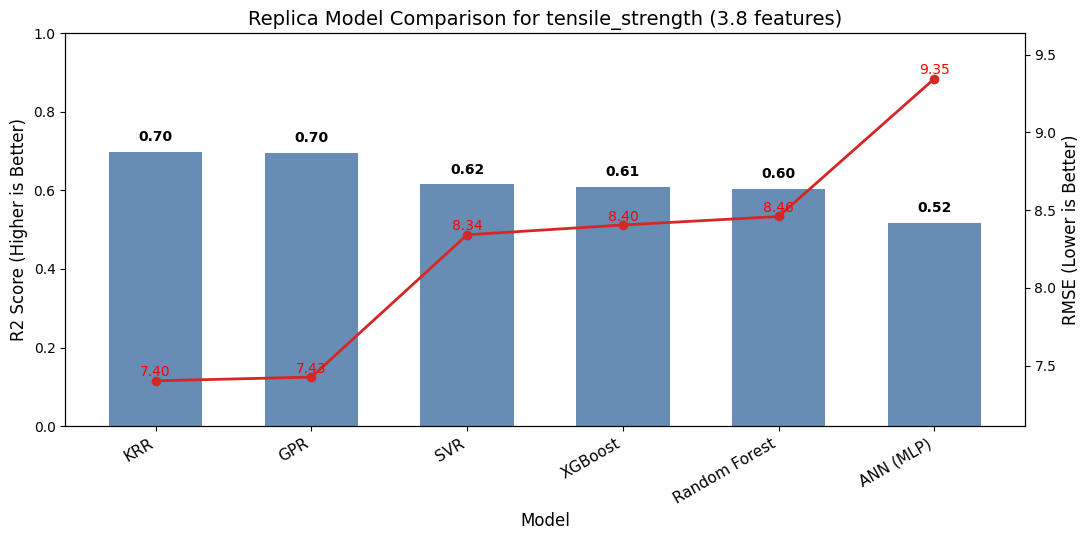


复刻旧版多模型选择 | 目标: elongation
样本数: 84 | 特征数: 17
 -> Random Forest: R²=0.5570, RMSE=179.4700
 -> XGBoost: R²=0.5721, RMSE=176.3897
 -> SVR: R²=0.5883, RMSE=173.0087
 -> GPR: R²=0.6354, RMSE=162.8242


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

 -> ANN (MLP): R²=-0.0585, RMSE=277.4099
 -> KRR: R²=0.5225, RMSE=186.3233


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/

,Target,Model,R2,RMSE,Samples,Feature_Count
0,elongation,GPR,0.635356,162.824250,84,17
1,elongation,SVR,0.588313,173.008721,84,17
2,elongation,XGBoost,0.572066,176.389668,84,17
3,elongation,Random Forest,0.556989,179.470042,84,17
4,elongation,KRR,0.522509,186.323269,84,17
5,elongation,ANN (MLP),-0.058460,277.409897,84,17


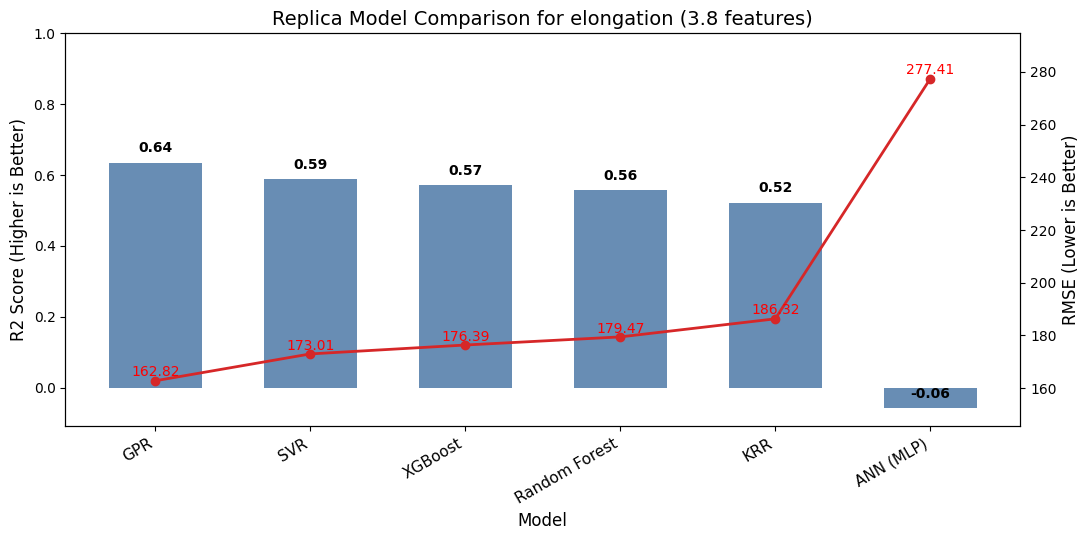


复刻旧版多模型选择 | 目标: healing_eff
样本数: 45 | 特征数: 19
 -> Random Forest: R²=0.3107, RMSE=13.6352
 -> XGBoost: R²=0.2367, RMSE=14.3484
 -> SVR: R²=0.1626, RMSE=15.0288


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul


 -> GPR: R²=0.1457, RMSE=15.1803


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/

 -> ANN (MLP): R²=-0.3192, RMSE=18.8637
 -> KRR: R²=-1.7325, RMSE=27.1489


/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yljj0528/Documents/GitHub/ML_DAPU/.venv/

,Target,Model,R2,RMSE,Samples,Feature_Count
0,healing_eff,Random Forest,0.310742,13.635183,45,19
1,healing_eff,XGBoost,0.236747,14.348425,45,19
2,healing_eff,SVR,0.162645,15.028822,45,19
3,healing_eff,GPR,0.145675,15.180339,45,19
4,healing_eff,ANN (MLP),-0.319213,18.863723,45,19
5,healing_eff,KRR,-1.732530,27.148913,45,19


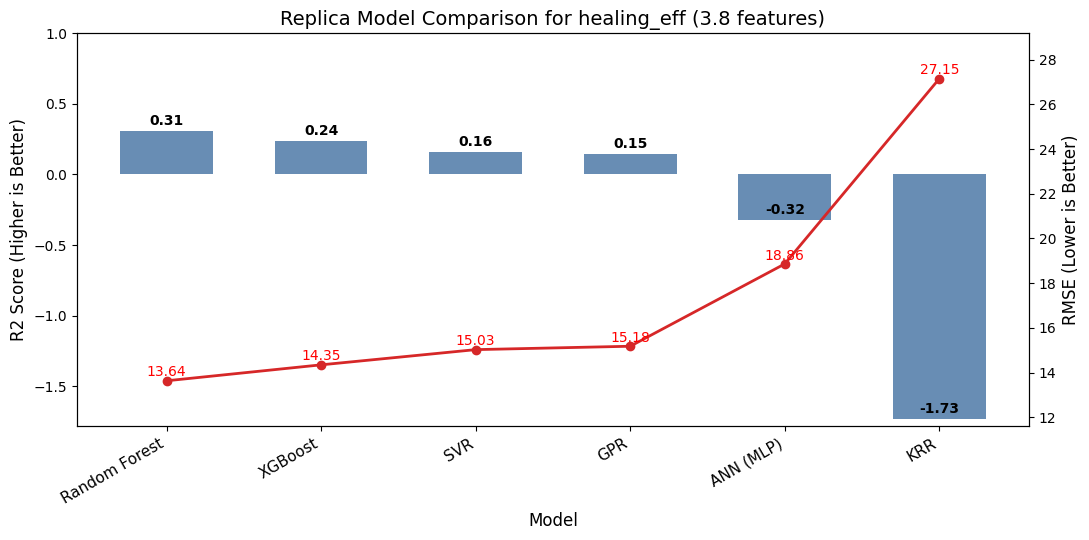


各目标在 3.8 新特征下的最优模型（复刻旧版口径）


,Target,Model,R2,RMSE,Samples,Feature_Count
0,elongation,GPR,0.635356,162.824250,84,17
1,healing_eff,Random Forest,0.310742,13.635183,45,19
2,tensile_strength,KRR,0.696985,7.402276,84,17


In [ ]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.neural_network import MLPRegressor
from sklearn.kernel_ridge import KernelRidge
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

_NB_ROOT = Path.cwd()
if not (_NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv').exists():
    _NB_ROOT = Path.cwd().parent
replica_file = _NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv'
replica_df = pd.read_csv(replica_file)

# 与主流程 3.8 特征口径一致（含 DA_Linker_Type；不含高共线/已弃用列）
features_mech_38_replica = [
    'Soft_Segment_Content',
    'Furan_Content',
    'Maleimide_Content',
    'Hard_Segment_Content',
    'NCO_OH_Ratio',
    'Extra_Crosslinker_Content',
    'DA_Linker_Type',
    'Furan_Type',
    'Network_Topology',
    'Polyol_Class',
    'Iso_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
]
features_heal_38_replica = features_mech_38_replica + ['healing_temperature', 'healing_time']

def get_clean_data_replica(target_col, feature_cols, df_local):
    missing_cols = [col for col in feature_cols if col not in df_local.columns]
    if missing_cols:
        raise ValueError(f'以下特征在 CSV 中找不到: {missing_cols}')
    data = df_local.dropna(subset=[target_col] + feature_cols).copy()
    X = data[feature_cols].values
    y = data[target_col].values
    return X, y

def evaluate_model_replica(model, X, y):
    y_pred = cross_val_predict(model, X, y, cv=LeaveOneOut(), n_jobs=-1)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    return r2, rmse, y_pred

replica_models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=500, max_depth=30, min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100, learning_rate=0.02, max_depth=5, subsample=0.7,
        colsample_bytree=0.8, random_state=42, n_jobs=-1
    ),
    'SVR': make_pipeline(StandardScaler(), SVR(C=500, gamma=1.0, epsilon=0.1)),
    'GPR': make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
            + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            n_restarts_optimizer=10,
            random_state=42,
            normalize_y=True,
        )
    ),
    'ANN (MLP)': make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(64,),
            activation='tanh',
            learning_rate_init=0.001,
            max_iter=2000,
            alpha=0.01,
            random_state=42,
            solver='lbfgs',
        )
    ),
    'KRR': make_pipeline(StandardScaler(), KernelRidge(kernel='rbf', gamma=0.1, alpha=0.04)),
}

replica_target_map = {
    'tensile_strength': features_mech_38_replica,
    'elongation': features_mech_38_replica,
    'healing_eff': features_heal_38_replica,
}

replica_all_results = []
replica_best_rows = []

for target_name, feature_list in replica_target_map.items():
    X_target, y_target = get_clean_data_replica(target_name, feature_list, replica_df)
    print('\n' + '=' * 100)
    print(f'复刻旧版多模型选择 | 目标: {target_name}')
    print('=' * 100)
    print(f'样本数: {len(y_target)} | 特征数: {len(feature_list)}')

    target_results = []
    for model_name, model in replica_models.items():
        r2, rmse, _ = evaluate_model_replica(model, X_target, y_target)
        target_results.append({
            'Target': target_name,
            'Model': model_name,
            'R2': r2,
            'RMSE': rmse,
            'Samples': len(y_target),
            'Feature_Count': len(feature_list),
        })
        print(f' -> {model_name}: R²={r2:.4f}, RMSE={rmse:.4f}')

    target_df = pd.DataFrame(target_results).sort_values(by='R2', ascending=False).reset_index(drop=True)
    display(target_df)

    best_row = target_df.iloc[0].to_dict()
    replica_best_rows.append(best_row)
    replica_all_results.extend(target_results)

    fig, ax1 = plt.subplots(figsize=(11, 5.5))
    x_pos = np.arange(len(target_df))
    ax1.bar(x_pos, target_df['R2'], alpha=0.85, width=0.6, color='#4E79A7')
    ax1.set_xlabel('Model', fontsize=12)
    ax1.set_ylabel('R2 Score (Higher is Better)', fontsize=12)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(target_df['Model'], rotation=30, ha='right', fontsize=11)
    r2_min = min(0, float(target_df['R2'].min()) - 0.05)
    r2_max = max(1.0, float(target_df['R2'].max()) + 0.08)
    ax1.set_ylim(r2_min, r2_max)
    for idx, r2_val in enumerate(target_df['R2']):
        ax1.text(idx, r2_val + 0.02, f'{r2_val:.2f}', ha='center', va='bottom', fontweight='bold')

    ax2 = ax1.twinx()
    ax2.plot(x_pos, target_df['RMSE'], marker='o', linewidth=2, linestyle='-', color='#D62728')
    ax2.set_ylabel('RMSE (Lower is Better)', fontsize=12)
    rmse_min, rmse_max = target_df['RMSE'].min(), target_df['RMSE'].max()
    pad = (rmse_max - rmse_min) * 0.15 if rmse_max != rmse_min else 1.0
    ax2.set_ylim(rmse_min - pad, rmse_max + pad)
    for idx, rmse_val in enumerate(target_df['RMSE']):
        ax2.text(idx, rmse_val + (pad * 0.03), f'{rmse_val:.2f}', ha='center', va='bottom', color='red')

    plt.title(f'Replica Model Comparison for {target_name} (3.8 features)', fontsize=14)
    ax1.grid(False)
    ax2.grid(False)
    fig.tight_layout()
    plt.show()

replica_result_df = pd.DataFrame(replica_all_results).sort_values(by=['Target', 'R2'], ascending=[True, False]).reset_index(drop=True)
replica_best_df = pd.DataFrame(replica_best_rows).sort_values(by='Target').reset_index(drop=True)

print('\n' + '=' * 100)
print('各目标在 3.8 新特征下的最优模型（复刻旧版口径）')
print('=' * 100)
display(replica_best_df[['Target', 'Model', 'R2', 'RMSE', 'Samples', 'Feature_Count']])


## 纠正版：多目标 `8` 模型严格选型 + `healing_eff` 样本诊断

上一个“复刻旧版”单元的问题在于：

- 它复刻的是 **旧 notebook 的固定超参数对比**，不是前面 `tensile_strength` 那个严格 `LOOCV + GridSearch` 口径；
- 因此 `tensile_strength` 会从前面最优的 `0.758` 掉到约 `0.697`；
- `healing_eff` 还叠加了一个更大的问题：**当前 `3.8` 数据里可用样本从旧版的 `37` 个变成了 `45` 个**。

所以这里分两步做：

1. 对 `tensile_strength` / `elongation` 使用当前 `3.8` 特征、严格 `LOOCV` 的 `8` 模型选型；
2. 对 `healing_eff` 同时给出：
   - 当前 `3.8` 全部可用样本（`45` 个）；
   - 与旧版严格对齐的 `37` 个样本；

这样就能把“模型逻辑变化”和“样本集变化”两个因素分开看清楚。

In [ ]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern
from sklearn.neural_network import MLPRegressor
from sklearn.kernel_ridge import KernelRidge
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

_NB_ROOT = Path.cwd()
if not (_NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv').exists():
    _NB_ROOT = Path.cwd().parent
new_file = _NB_ROOT / 'forecast_ML_3.8' / 'Final_Features_3.8.csv'
old_file = _NB_ROOT / 'forecast_ML_1.9' / 'Final_Features_Ultimate_all_deletion.csv'

df_new_multi = pd.read_csv(new_file)
df_old_multi = pd.read_csv(old_file)

features_mech_current = [
    'Soft_Segment_Content',
    'Furan_Content',
    'Maleimide_Content',
    'Hard_Segment_Content',
    'NCO_OH_Ratio',
    'Extra_Crosslinker_Content',
    'Furan_Type',
    'Network_Topology',
    'Polyol_Class',
    'Iso_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
]
features_heal_current = features_mech_current + ['healing_temperature', 'healing_time']

old_heal_features = [
    'X1_Soft_Content',
    'X2_DA_Content',
    'X3_Hard_Content',
    'X4_R_Ratio',
    'X5_Add_Crosslink',
    'DA_Linker_Type',
    'Network_Topology',
    'Add_Crosslinker_Flag',
    'Polyol_Class',
    'Iso_Class',
    'Extender_Class',
    'Soft_Mw',
    'Constraint_Factor',
    'Hard_Symmetry',
    'Soft_Cryst',
    'Synergy_Feature',
    'healing_temperature',
    'healing_time',
]

old_heal_valid = df_old_multi.dropna(subset=['healing_eff'] + old_heal_features).copy()
old_heal_ids = sorted(old_heal_valid['sample_id'].unique().tolist())
new_heal_valid = df_new_multi.dropna(subset=['healing_eff'] + features_heal_current).copy()
extra_heal_ids = sorted(set(new_heal_valid['sample_id']) - set(old_heal_ids))

print('healing_eff 样本诊断')
print(f"- 旧版可用样本数: {len(old_heal_valid)}")
print(f"- 当前 3.8 可用样本数: {len(new_heal_valid)}")
print(f"- 当前新增样本数: {len(extra_heal_ids)}")
print(f"- 当前新增样本 ID: {extra_heal_ids}")

strict_cv_multi = LeaveOneOut()

strict_models_multi = {
    'MLR': LinearRegression(),
    'Ridge': make_pipeline(StandardScaler(), Ridge(random_state=42)),
    'LASSO': make_pipeline(StandardScaler(), Lasso(random_state=42, max_iter=20000)),
    'SVR': make_pipeline(StandardScaler(), SVR(kernel='rbf')),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=1),
    'GPR': make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
            + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            random_state=42
        )
    ),
    'MLP': make_pipeline(StandardScaler(), MLPRegressor(random_state=42, max_iter=5000)),
    'KRR': make_pipeline(StandardScaler(), KernelRidge(kernel='rbf')),
}

strict_param_spaces_multi = {
    'MLR': {},
    'Ridge': {'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    'LASSO': {'lasso__alpha': [0.001, 0.005, 0.01, 0.05, 0.1]},
    'SVR': {
        'svr__C': [1, 10, 50, 100, 300, 500, 1000],
        'svr__gamma': ['scale', 0.001, 0.01, 0.1, 0.5, 1.0],
        'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    },
    'Random Forest': {
        'n_estimators': [300, 600, 800],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 0.7],
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500],
        'learning_rate': [0.02, 0.05],
        'max_depth': [3, 4, 6],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8],
        'reg_alpha': [0.0, 1.0],
        'reg_lambda': [1.0, 5.0],
    },
    'GPR': {
        'gaussianprocessregressor__kernel': [
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
            1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1)),
        ],
        'gaussianprocessregressor__alpha': [1e-10, 1e-6, 1e-4],
        'gaussianprocessregressor__normalize_y': [True, False],
        'gaussianprocessregressor__n_restarts_optimizer': [0, 5, 10],
    },
    'MLP': {
        'mlpregressor__hidden_layer_sizes': [(32,), (64,), (64, 32)],
        'mlpregressor__activation': ['tanh'],
        'mlpregressor__solver': ['lbfgs', 'adam'],
        'mlpregressor__alpha': [0.01, 0.1],
        'mlpregressor__learning_rate_init': [0.0005, 0.001],
    },
    'KRR': {
        'kernelridge__alpha': [1e-3, 1e-2, 0.04, 0.05, 0.1, 1, 10],
        'kernelridge__gamma': [1e-3, 1e-2, 0.1, 0.5, 1, 5],
    },
}

def strict_tune_and_eval_multi(model_name, model, param_space, X, y):
    if not param_space:
        model.fit(X, y)
        y_pred = cross_val_predict(model, X, y, cv=strict_cv_multi, n_jobs=-1)
        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        return {
            'best_model': model,
            'route': 'Default(NoTune)',
            'best_params': {},
            'r2': r2,
            'rmse': rmse,
        }
    total_combinations = 1
    for values in param_space.values():
        total_combinations *= len(values)
    yv = np.asarray(y).ravel()
    y_pred = np.zeros(len(yv))
    inner_scores = []
    fold_params: list = []
    Xdf = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
    yser = pd.Series(yv)
    for tr, te in strict_cv_multi.split(Xdf):
        X_tr, X_te = Xdf.iloc[tr], Xdf.iloc[te]
        y_tr = yser.iloc[tr]
        nn = len(tr)
        ns = min(5, nn)
        inner = KFold(n_splits=ns, shuffle=True, random_state=42) if ns >= 2 else None
        est = clone(model)
        if inner is None:
            est.fit(X_tr, y_tr)
            y_pred[te[0]] = float(est.predict(X_te)[0])
            fold_params.append({})
            continue
        search = GridSearchCV(
            est, param_space, cv=inner, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0,
        )
        search.fit(X_tr, y_tr)
        y_pred[te[0]] = float(search.predict(X_te)[0])
        inner_scores.append(float(np.sqrt(-search.best_score_)))
        fold_params.append(search.best_params_)
    r2 = r2_score(yv, y_pred)
    rmse = np.sqrt(mean_squared_error(yv, y_pred))
    import json as _j
    from collections import Counter as _C
    keys = [_j.dumps(p, sort_keys=True, default=str) for p in fold_params if p]
    maj = _j.loads(_C(keys).most_common(1)[0][0]) if keys else {}
    best_model = clone(model)
    if maj:
        best_model.set_params(**maj)
    best_model.fit(Xdf, yser)
    return {
        'best_model': best_model,
        'route': f'StrictNestedGrid({total_combinations}组合)',
        'best_params': maj,
        'r2': r2,
        'rmse': rmse,
    }

target_runs = [
    ('tensile_strength', df_new_multi, features_mech_current, 'CurrentFull84'),
    ('elongation', df_new_multi, features_mech_current, 'CurrentFull84'),
    ('healing_eff', new_heal_valid, features_heal_current, 'CurrentFull45'),
    ('healing_eff', new_heal_valid[new_heal_valid['sample_id'].isin(old_heal_ids)].copy(), features_heal_current, 'AlignedOld37'),
]

multi_target_results = []
multi_target_best = []

for target_name, df_used, feature_cols, subset_name in target_runs:
    data = df_used.dropna(subset=[target_name] + feature_cols).copy()
    X = data[feature_cols]
    y = data[target_name]
    print('\n' + '=' * 110)
    print(f'严格 8 模型选型 | Target={target_name} | Subset={subset_name}')
    print('=' * 110)
    print(f'样本数: {len(y)} | 特征数: {len(feature_cols)}')

    target_rows = []
    for model_name, model in strict_models_multi.items():
        res = strict_tune_and_eval_multi(model_name, model, strict_param_spaces_multi[model_name], X, y)
        target_rows.append({
            'Target': target_name,
            'Subset': subset_name,
            'Model': model_name,
            'Route': res['route'],
            'R2': res['r2'],
            'RMSE': res['rmse'],
            'Samples': len(y),
            'Feature_Count': len(feature_cols),
            'Best_Params': res['best_params'],
        })
        print(f" -> {model_name}: R²={res['r2']:.4f}, RMSE={res['rmse']:.4f}")

    target_df = pd.DataFrame(target_rows).sort_values(by='R2', ascending=False).reset_index(drop=True)
    display(target_df[['Target', 'Subset', 'Model', 'R2', 'RMSE', 'Samples', 'Feature_Count']])
    multi_target_results.extend(target_rows)
    multi_target_best.append(target_df.iloc[0].to_dict())

multi_result_df = pd.DataFrame(multi_target_results).sort_values(by=['Target', 'Subset', 'R2'], ascending=[True, True, False]).reset_index(drop=True)
multi_best_df = pd.DataFrame(multi_target_best).sort_values(by=['Target', 'Subset']).reset_index(drop=True)

print('\n' + '=' * 110)
print('纠正版结果汇总：各目标 / 各样本口径下的最优模型')
print('=' * 110)
display(multi_best_df[['Target', 'Subset', 'Model', 'R2', 'RMSE', 'Samples', 'Feature_Count']])

healing_compare = multi_best_df[multi_best_df['Target'] == 'healing_eff'][['Subset', 'Model', 'R2', 'RMSE', 'Samples']]
print('\nhealing_eff 诊断结论：')
display(healing_compare)
